# Notebook 06 Data Wrangling & EDA: Study Behavior
**Proyek Analisis Data: HAPI (Human Activity Pattern Intelligence)**

### Profil Proyek & Tim
- **Tema Capstone:** Healthy Lives & Well-being
- **Target User:** Mahasiswa (fokus pada aspek akademik & lingkungan belajar)
- **Tujuan Proyek:** Pengembangan *platform* Webapp untuk *mood management & tracker* serta diagnosis mandiri tingkat kelelahan (*fatigue*).
- **Tim DS:** Greycia Febrina Michelle (CDCC700D6X2644) & Khazel Hayfa Yosmi (CDCC308D6X0629)

### Sumber Dataset
Analisis pada notebook ini menggunakan dua sumber dataset yang saling melengkapi:

1. **Student Performance and Learning Style**
   - Digunakan untuk menganalisis performa akademik, kebiasaan belajar, serta karakteristik gaya belajar mahasiswa.
   - Dataset ini membantu mengidentifikasi faktor perilaku yang berpotensi memengaruhi kesejahteraan akademik.

2. **Student Academic Stress Real World Dataset**
   - Digunakan untuk memahami kondisi stres akademik mahasiswa berdasarkan data dunia nyata.
   - Dataset ini memberikan gambaran mengenai tingkat tekanan akademik yang dialami mahasiswa dalam berbagai situasi pembelajaran.

### Tujuan Notebook
Melakukan Data Wrangling (*Gathering, Assessing, Cleaning*) dan Exploratory Data Analysis (EDA) pada kedua dataset untuk memahami hubungan antara perilaku belajar, performa akademik, dan tingkat stres mahasiswa. Hasil analisis akan digunakan sebagai dasar pengambilan keputusan dalam pengembangan fitur utama aplikasi HAPI, khususnya yang berkaitan dengan pemantauan kondisi belajar, pengelolaan suasana hati, dan deteksi dini risiko *fatigue*.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

PALETTE = ['#00bcff','#00adfd','#009efa','#008ff6','#007ff1',
           '#006eea','#005ce1','#004ad6','#0034c8']
C_MAIN = '#007ff1'
C_DARK = '#0034c8'
C_LIGHT = '#00bcff'
C_GREY = '#e0e0e0'
HAPI_CMAP = LinearSegmentedColormap.from_list('hapi', [C_LIGHT, C_DARK], N=256)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})


ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'data').exists(): break
    ROOT = ROOT.parent

BASE   = ROOT / 'data' / 'raw' / 'supporting' / 'kelompok2-aktivitas-dan-kebiasaan-belajar'
RAW_LB = BASE / 'learning_behavior.csv'
RAW_AS = BASE / 'academic_stress_rw.csv'
CLEAN_LB = ROOT / 'data' / 'clean' / 'supporting' / 'learning_behavior_clean.csv'
CLEAN_AS = ROOT / 'data' / 'clean' / 'supporting' / 'academic_stress_clean.csv'
CLEAN_LB.parent.mkdir(parents=True, exist_ok=True)

DROP_LB = ['EduTech', 'OnlineCourses', 'LearningStyle', 'Internet', 'Resources']

print(f'ROOT              : {ROOT}')
print(f'learning_behavior : {RAW_LB.exists()}')
print(f'academic_stress   : {RAW_AS.exists()}')
print('Setup selesai.')

ROOT              : d:\Proyek_Analisis_Burnout
learning_behavior : True
academic_stress   : True
Setup selesai.


**Inisialisasi Lingkungan Kerja**

Dua dataset diproses dalam satu notebook karena menjawab business questions yang sama. Path dideteksi otomatis dari root proyek.

## Gathering Data

In [2]:
df_lb = pd.read_csv(RAW_LB)
df_as = pd.read_csv(RAW_AS)
print(f'learning_behavior : {df_lb.shape[0]:,} baris, {df_lb.shape[1]} kolom')
print(f'Kolom: {df_lb.columns.tolist()}')
print(f'\nacademic_stress   : {df_as.shape[0]:,} baris, {df_as.shape[1]} kolom')
print(f'Kolom: {df_as.columns.tolist()}')

learning_behavior : 14,003 baris, 16 kolom
Kolom: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

academic_stress   : 140 baris, 9 kolom
Kolom: ['Timestamp', 'Your Academic Stage', 'Peer pressure', 'Academic pressure from your home', 'Study Environment', 'What coping strategy you use as a student?', 'Do you have any bad habits like smoking, drinking on a daily basis?', 'What would you rate the academic  competition in your student life', 'Rate your academic stress index ']


**Pemuatan Dua Dataset**

- `learning_behavior` memuat fitur perilaku belajar terstruktur dengan nama kolom standar.
- `academic_stress_rw` memuat nama kolom panjang dari Google Form yang perlu di-rename saat cleaning.

## Assessing Data

In [3]:
print('Learning Behavior: Shape, Tipe Data, Missing Values, Duplikat')
print(f'Shape: {df_lb.shape} | Duplikat: {df_lb.duplicated().sum()}')
mv = df_lb.isnull().sum()
print(f'Missing:\n{mv[mv>0] if mv.sum()>0 else "Tidak ada"}')
print('\nStatistik Deskriptif:')
print(df_lb.describe(include='all').round(3))

Learning Behavior: Shape, Tipe Data, Missing Values, Duplikat
Shape: (14003, 16) | Duplikat: 1534
Missing:
Tidak ada

Statistik Deskriptif:
       StudyHours  Attendance  Resources  Extracurricular  Motivation  \
count  14003.0000  14003.0000 14003.0000       14003.0000  14003.0000   
mean      19.9870     80.1940     1.1040           0.5940      0.9060   
std        5.8910     11.4720     0.6970           0.4910      0.6960   
min        5.0000     60.0000     0.0000           0.0000      0.0000   
25%       16.0000     70.0000     1.0000           0.0000      0.0000   
50%       20.0000     80.0000     1.0000           1.0000      1.0000   
75%       24.0000     90.0000     2.0000           1.0000      1.0000   
max       44.0000    100.0000     2.0000           1.0000      2.0000   

        Internet     Gender        Age  LearningStyle  OnlineCourses  \
count 14003.0000 14003.0000 14003.0000     14003.0000     14003.0000   
mean      0.9260     0.5520    23.5320         1.5150     

In [4]:
print('Academic Stress Real World: Shape, Tipe Data, Missing Values, Duplikat')
print(f'Shape: {df_as.shape} | Duplikat: {df_as.duplicated().sum()}')
mv = df_as.isnull().sum()
print(f'Missing:\n{mv[mv>0] if mv.sum()>0 else "Tidak ada"}')
print('\nStatistik Deskriptif:')
print(df_as.describe(include='all').round(3))

Academic Stress Real World: Shape, Tipe Data, Missing Values, Duplikat
Shape: (140, 9) | Duplikat: 0
Missing:
Study Environment    1
dtype: int64

Statistik Deskriptif:
                  Timestamp Your Academic Stage  Peer pressure  \
count                   140                 140       140.0000   
unique                  140                   3            NaN   
top     24/07/2025 22:05:39       undergraduate            NaN   
freq                      1                 100            NaN   
mean                    NaN                 NaN         3.0710   
std                     NaN                 NaN         1.0840   
min                     NaN                 NaN         1.0000   
25%                     NaN                 NaN         2.0000   
50%                     NaN                 NaN         3.0000   
75%                     NaN                 NaN         4.0000   
max                     NaN                 NaN         5.0000   

        Academic pressure from your ho

**Profil Dataset**

| Dataset | Temuan |
|---|---|
| learning_behavior | Kolom `EduTech`, `OnlineCourses`, `LearningStyle` kurang relevan untuk analisis burnout mahasiswa |
| academic_stress_rw | Nama kolom panjang dari Google Form perlu di-rename; kolom `Timestamp` dan `bad habits` dihapus |

## Cleaning Data

In [5]:
df_lb_c = df_lb.copy()
before = len(df_lb_c)
df_lb_c = df_lb_c.drop_duplicates()
print(f'Drop Duplikat: {before-len(df_lb_c)} baris, sisa {len(df_lb_c):,}')

df_lb_c = df_lb_c.drop(columns=[c for c in DROP_LB if c in df_lb_c.columns])
print(f'Drop Kolom: {DROP_LB}')

for col in df_lb_c.select_dtypes(include=[np.number]).columns:
    n = df_lb_c[col].isnull().sum()
    if n>0:
        df_lb_c[col]=df_lb_c[col].fillna(df_lb_c[col].median())
        print(f'Fill {col}: {n}')
for col in df_lb_c.select_dtypes(include='object').columns:
    n = df_lb_c[col].isnull().sum()
    if n>0:
        df_lb_c[col]=df_lb_c[col].fillna(df_lb_c[col].mode()[0])
        print(f'Fill {col}: {n}')

print(f'Missing Setelah Fill: {df_lb_c.isnull().sum().sum()}')
print(f'Shape Akhir: {df_lb_c.shape}')
df_lb_c.to_csv(CLEAN_LB, index=False)
print(f'Disimpan: {CLEAN_LB}')

Drop Duplikat: 1534 baris, sisa 12,469


Drop Kolom: ['EduTech', 'OnlineCourses', 'LearningStyle', 'Internet', 'Resources']
Missing Setelah Fill: 0
Shape Akhir: (12469, 11)
Disimpan: d:\Proyek_Analisis_Burnout\data\clean\supporting\learning_behavior_clean.csv


In [6]:
df_as_c = df_as.copy()
before = len(df_as_c)
df_as_c = df_as_c.drop_duplicates()
print(f'Drop Duplikat: {before-len(df_as_c)}')

drop_ts = [c for c in df_as_c.columns if 'timestamp' in c.lower() or 'bad habits' in c.lower() or 'smoking' in c.lower()]
df_as_c = df_as_c.drop(columns=drop_ts, errors='ignore')
print(f'Drop Kolom: {drop_ts}')

rmap = {}
for col in df_as_c.columns:
    cl = col.lower()
    if 'academic stage' in cl: rmap[col]='academic_stage'
    elif 'peer pressure' in cl: rmap[col]='peer_pressure'
    elif 'pressure from your home' in cl: rmap[col]='home_pressure'
    elif 'study environment' in cl: rmap[col]='study_environment'
    elif 'coping strategy' in cl: rmap[col]='coping_strategy'
    elif 'competition' in cl: rmap[col]='academic_competition'
    elif 'stress index' in cl: rmap[col]='academic_stress_index'
df_as_c = df_as_c.rename(columns=rmap)
print(f'Rename: {rmap}')

for col in df_as_c.select_dtypes(include=[np.number]).columns:
    n = df_as_c[col].isnull().sum()
    if n>0:
        df_as_c[col]=df_as_c[col].fillna(df_as_c[col].median())
        print(f'Fill {col}: {n}')
for col in df_as_c.select_dtypes(include='object').columns:
    n = df_as_c[col].isnull().sum()
    if n>0:
        df_as_c[col]=df_as_c[col].fillna(df_as_c[col].mode()[0])
        print(f'Fill {col}: {n}')

print(f'Missing Setelah Fill: {df_as_c.isnull().sum().sum()}')
print(f'Shape Akhir: {df_as_c.shape}')
df_as_c.to_csv(CLEAN_AS, index=False)
print(f'Disimpan: {CLEAN_AS}')

Drop Duplikat: 0
Drop Kolom: ['Timestamp', 'Do you have any bad habits like smoking, drinking on a daily basis?']
Rename: {'Your Academic Stage': 'academic_stage', 'Peer pressure': 'peer_pressure', 'Academic pressure from your home': 'home_pressure', 'Study Environment': 'study_environment', 'What coping strategy you use as a student?': 'coping_strategy', 'What would you rate the academic  competition in your student life': 'academic_competition', 'Rate your academic stress index ': 'academic_stress_index'}
Fill study_environment: 1
Missing Setelah Fill: 0
Shape Akhir: (140, 7)
Disimpan: d:\Proyek_Analisis_Burnout\data\clean\supporting\academic_stress_clean.csv


**Pembersihan Dataset Study Behavior**

- `learning_behavior`: lima kolom kurang relevan dihapus; duplikat dan missing values ditangani.
- `academic_stress_rw`: kolom Timestamp dan bad habits dihapus; nama kolom panjang Google Form dipersingkat via *substring matching* agar konsisten dengan kolom lain dalam proyek.

## Exploratory Data Analysis

EDA dilakukan dalam tiga tahap berurutan:
1. **Univariat:** distribusi dan karakteristik tiap variabel secara mandiri
2. **Bivariat:** hubungan antara dua variabel
3. **Multivariat:** interaksi tiga variabel atau lebih

In [7]:
df_lb_c = pd.read_csv(CLEAN_LB)
df_as_c = pd.read_csv(CLEAN_AS)
num_lb = df_lb_c.select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolom numerik learning_behavior: {num_lb}')

Kolom numerik learning_behavior: ['StudyHours', 'Attendance', 'Extracurricular', 'Motivation', 'Gender', 'Age', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'StressLevel', 'FinalGrade']


### Analisis Univariat
Memeriksa satu variabel secara mandiri.

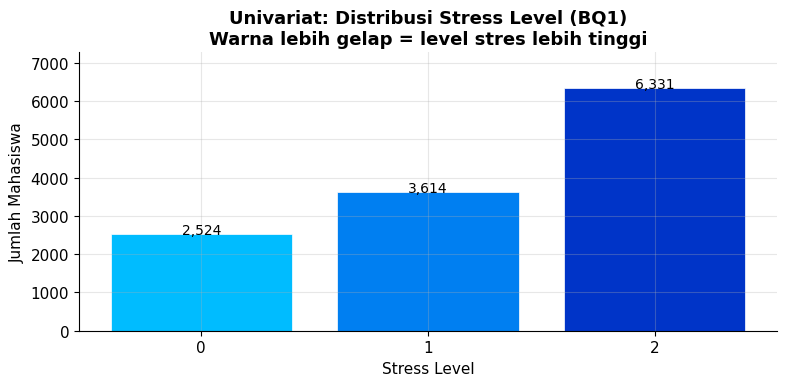

StressLevel
0    2524
1    3614
2    6331
Name: count, dtype: int64


In [8]:
if 'StressLevel' in df_lb_c.columns:
    sc = df_lb_c['StressLevel'].value_counts().sort_index()
    n = len(sc)
    bar_colors = [PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i in range(n)]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(sc.index.astype(str), sc.values, color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, sc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:,}', ha='center', fontsize=10)
    ax.set_ylim(0, sc.max()*1.15)
    ax.set_xlabel('Stress Level')
    ax.set_ylabel('Jumlah Mahasiswa')
    ax.set_title('Univariat: Distribusi Stress Level (BQ1)\nWarna lebih gelap = level stres lebih tinggi',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('uni_stresslevel_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(sc)

**Distribusi Stress Level**

Data ordinal menggunakan gradasi warna dari terang ke gelap. Warna lebih gelap merepresentasikan level stres lebih tinggi sesuai prinsip *darker-is-more*.

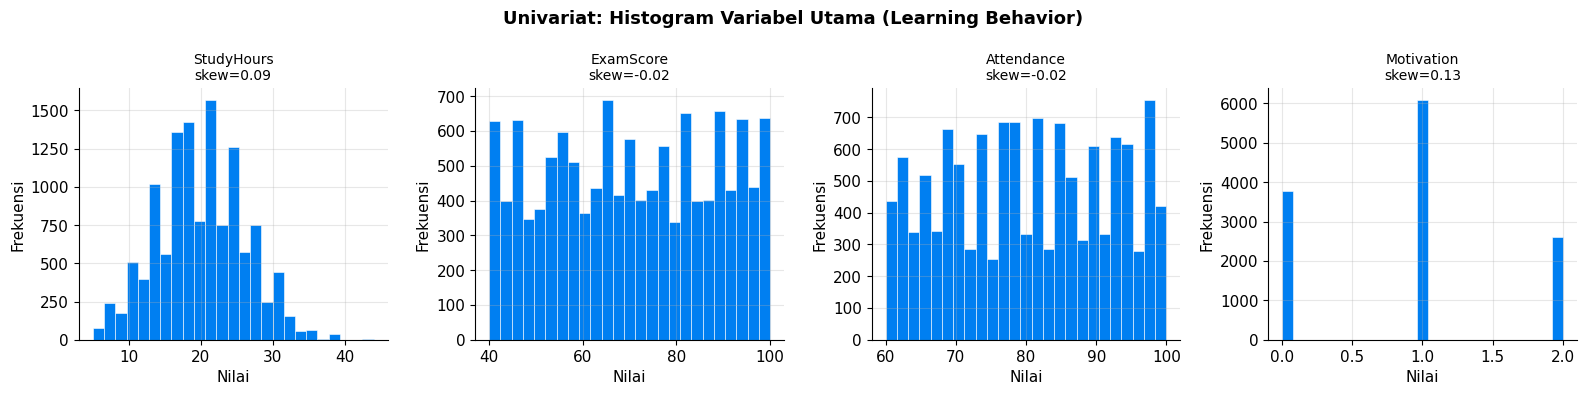

Skewness:
StudyHours    0.0860
ExamScore    -0.0150
Attendance   -0.0170
Motivation    0.1350
dtype: float64


In [9]:
num_targets = [c for c in ['StudyHours','ExamScore','Attendance','Motivation'] if c in df_lb_c.columns]
n = len(num_targets)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1: axes = [axes]
for ax, col in zip(axes, num_targets):
    skew_val = df_lb_c[col].skew()
    ax.hist(df_lb_c[col].dropna(), bins=25, color=C_MAIN, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=10)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
fig.suptitle('Univariat: Histogram Variabel Utama (Learning Behavior)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_histograms_lb.png', dpi=150, bbox_inches='tight')
plt.show()

print('Skewness:')
print(df_lb_c[num_targets].skew().round(3))

**Histogram Variabel Utama**

Nilai skewness ditampilkan di judul setiap histogram. Distribusi sangat miring (`|skew| > 1`) akan dipertimbangkan dalam pemilihan metode uji statistik di tahap bivariat.

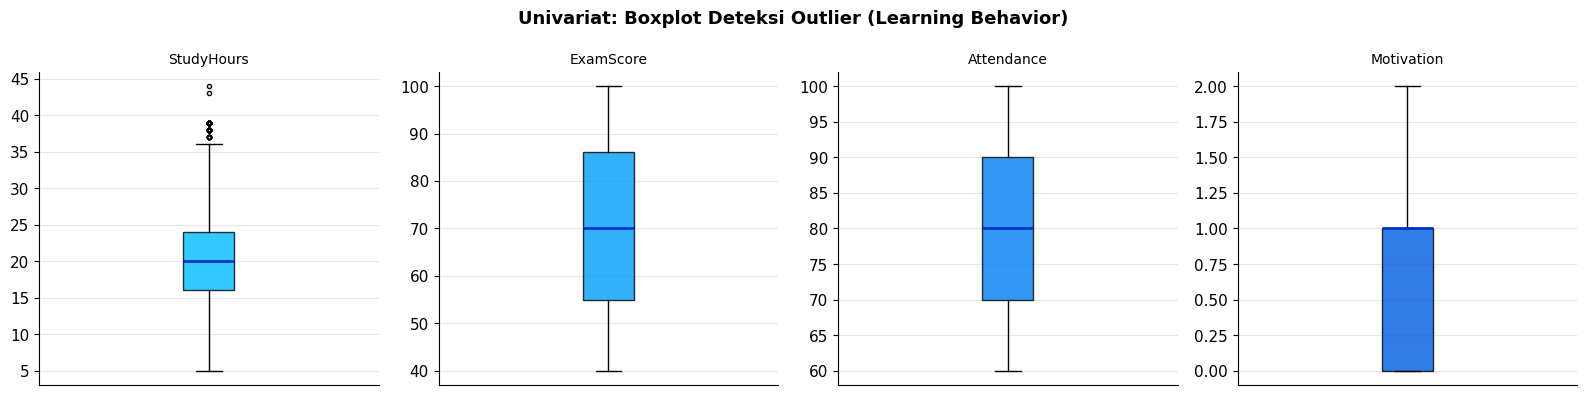

In [10]:
if num_targets:
    fig, axes = plt.subplots(1, len(num_targets), figsize=(4*len(num_targets), 4))
    if len(num_targets)==1: axes=[axes]
    for i, (ax, col) in enumerate(zip(axes, num_targets)):
        bp = ax.boxplot(df_lb_c[col].dropna(), patch_artist=True,
                        medianprops=dict(color=C_DARK, linewidth=2),
                        flierprops=dict(marker='o', markersize=3, color=C_DARK))
        bp['boxes'][0].set_facecolor(PALETTE[i*2 % len(PALETTE)])
        bp['boxes'][0].set_alpha(0.8)
        ax.set_title(col, fontsize=10)
        ax.set_xticks([])
    fig.suptitle('Univariat: Boxplot Deteksi Outlier (Learning Behavior)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('uni_boxplot_lb.png', dpi=150, bbox_inches='tight')
    plt.show()

**Deteksi Outlier**

Boxplot mengidentifikasi pencilan ekstrem. Titik di luar *whisker* perlu dievaluasi: outlier pada `StudyHours` > 16 jam per hari tidak masuk akal secara fisik dan perlu diclip.

### Analisis Bivariat
Meneliti hubungan antara dua variabel.

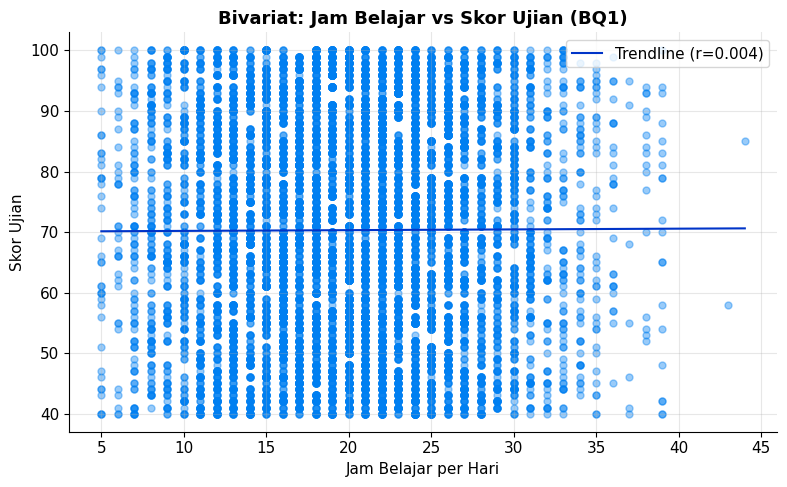

Korelasi Pearson StudyHours vs ExamScore: r = 0.004


In [11]:
if 'StudyHours' in df_lb_c.columns and 'ExamScore' in df_lb_c.columns:
    r = df_lb_c['StudyHours'].corr(df_lb_c['ExamScore'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_lb_c['StudyHours'], df_lb_c['ExamScore'], alpha=0.4, color=C_MAIN, s=25)
    m, b = np.polyfit(df_lb_c['StudyHours'].dropna(), df_lb_c['ExamScore'].dropna(), 1)
    x_ = np.linspace(df_lb_c['StudyHours'].min(), df_lb_c['StudyHours'].max(), 100)
    ax.plot(x_, m*x_+b, color=C_DARK, linewidth=1.5, label=f'Trendline (r={r:.3f})')
    ax.set_xlabel('Jam Belajar per Hari')
    ax.set_ylabel('Skor Ujian')
    ax.legend()
    ax.set_title('Bivariat: Jam Belajar vs Skor Ujian (BQ1)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('biv_studyhours_vs_exam.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Korelasi Pearson StudyHours vs ExamScore: r = {r:.3f}')

**Jam Belajar vs Skor Ujian**

*Scatter plot* dengan trendline untuk mengidentifikasi arah korelasi. Nilai `r` mendekati 1 menandakan korelasi positif kuat — semakin banyak jam belajar, semakin tinggi skor ujian.

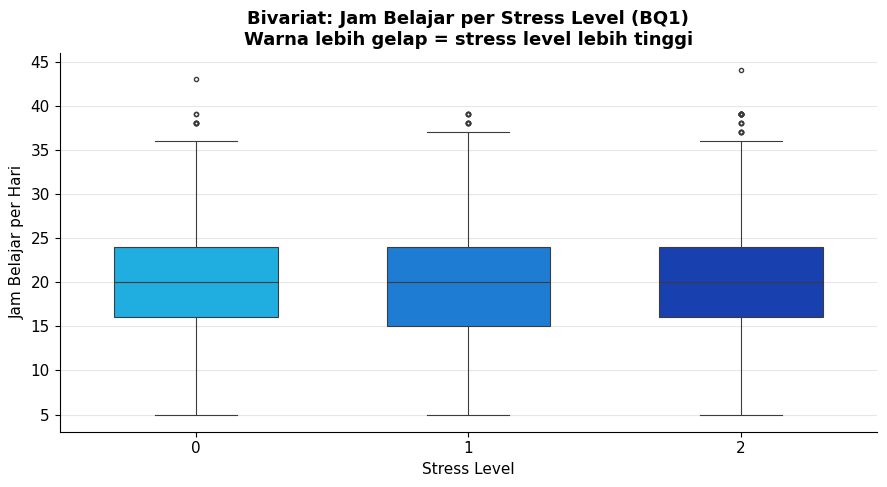

Rata-rata jam belajar per stress level:
               mean  median
StressLevel                
0           19.9640 20.0000
1           20.0410 20.0000
2           20.0590 20.0000


In [12]:
if 'StressLevel' in df_lb_c.columns and 'StudyHours' in df_lb_c.columns:
    order = sorted(df_lb_c['StressLevel'].dropna().unique())
    n = len(order)
    pal = {s: PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i, s in enumerate(order)}

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=df_lb_c, x='StressLevel', y='StudyHours',
        hue='StressLevel', order=order, hue_order=order,
        palette=pal, legend=False, ax=ax,
        linewidth=0.8, width=0.6,
        flierprops=dict(marker='o', markersize=3)
    )
    ax.set_xlabel('Stress Level')
    ax.set_ylabel('Jam Belajar per Hari')
    ax.set_title('Bivariat: Jam Belajar per Stress Level (BQ1)\nWarna lebih gelap = stress level lebih tinggi',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('biv_stresslevel_vs_studyhours.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Rata-rata jam belajar per stress level:')
    print(df_lb_c.groupby('StressLevel')['StudyHours'].agg(['mean','median']).round(3))

**Jam Belajar per Stress Level**

Boxplot multipel membandingkan distribusi `StudyHours` di tiap kelompok `StressLevel`. Parameter `hue='StressLevel'` dengan `legend=False` digunakan sesuai API seaborn v0.13+ untuk menghindari *FutureWarning*.

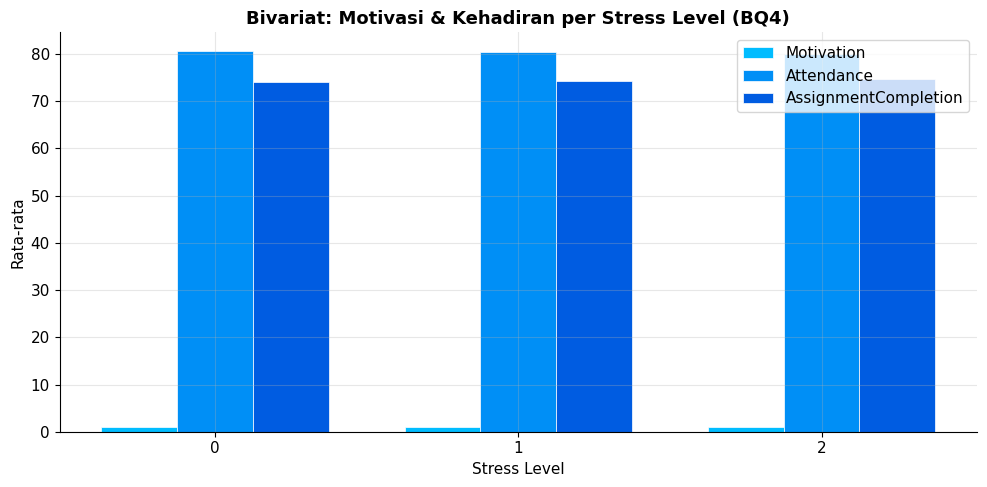

Rata-rata per stress level:
             Motivation  Attendance  AssignmentCompletion
StressLevel                                              
0                0.9100     80.5590               74.1650
1                0.9070     80.3500               74.3580
2                0.9060     80.0480               74.7450


In [13]:
feat_bq4 = [c for c in ['Motivation','Attendance','AssignmentCompletion'] if c in df_lb_c.columns]
if feat_bq4 and 'StressLevel' in df_lb_c.columns:
    order = sorted(df_lb_c['StressLevel'].dropna().unique())
    grouped = df_lb_c.groupby('StressLevel')[feat_bq4].mean().loc[order]
    x = np.arange(len(grouped))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, col in enumerate(feat_bq4):
        ax.bar(x+i*width, grouped[col], width=width, label=col,
               color=PALETTE[i*3], edgecolor='white', linewidth=0.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels(order)
    ax.set_xlabel('Stress Level')
    ax.set_ylabel('Rata-rata')
    ax.set_title('Bivariat: Motivasi & Kehadiran per Stress Level (BQ4)',
                 fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('biv_motivation_vs_stress.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Rata-rata per stress level:')
    print(grouped.round(3))

**Motivasi & Kehadiran per Stress Level**

*Clustered bar chart* membandingkan tiga sub-metrik perilaku (`Motivation`, `Attendance`, `AssignmentCompletion`) di setiap level stres. Pola penurunan nilai dari stres rendah ke tinggi mengindikasikan hubungan negatif antara keaktifan akademik dan stres.

### Analisis Multivariat

Menyelidiki interaksi tiga variabel atau lebih.
---

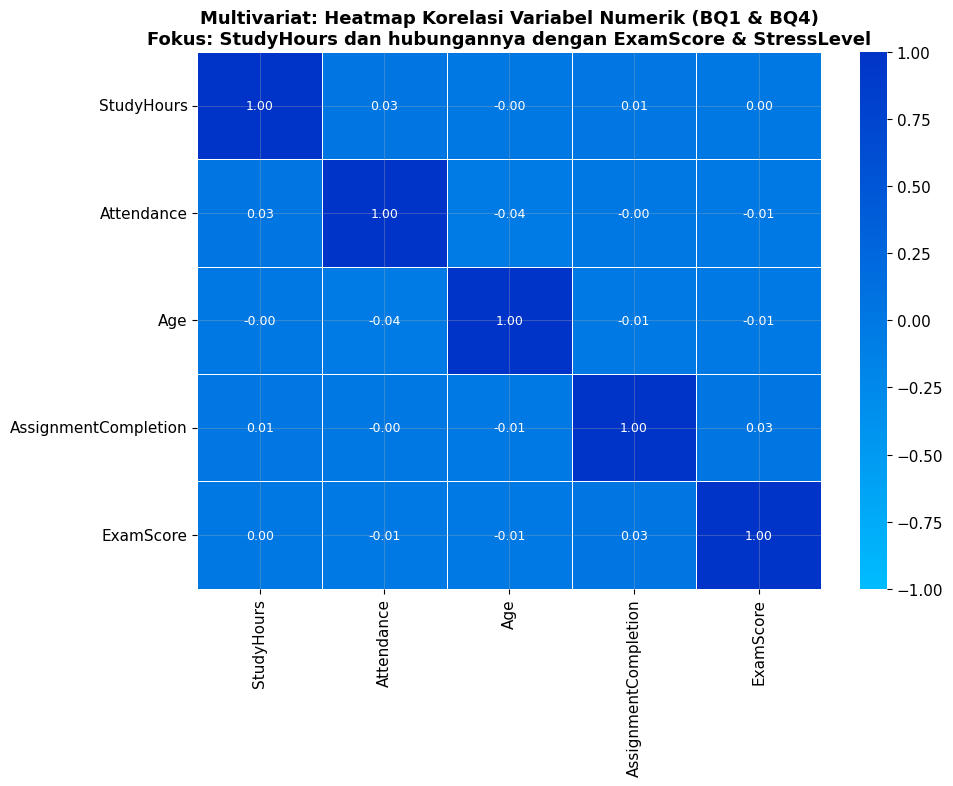

Korelasi StudyHours terhadap variabel lain:
Attendance              0.0280
AssignmentCompletion    0.0090
ExamScore               0.0040
Age                    -0.0010
Name: StudyHours, dtype: float64


In [14]:
corr_cols = [c for c in num_lb if df_lb_c[c].nunique() > 5]
corr = df_lb_c[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=HAPI_CMAP,
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 9})
ax.set_title('Multivariat: Heatmap Korelasi Variabel Numerik (BQ1 & BQ4)\nFokus: StudyHours dan hubungannya dengan ExamScore & StressLevel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multi_heatmap_lb.png', dpi=150, bbox_inches='tight')
plt.show()

if 'StudyHours' in corr.columns:
    print('Korelasi StudyHours terhadap variabel lain:')
    print(corr['StudyHours'].drop('StudyHours').sort_values(ascending=False).round(3))

**Heatmap Korelasi**

Heatmap memetakan koefisien korelasi semua variabel numerik sekaligus. `linewidths=0.5` dan `linecolor='white'` memisahkan sel secara visual untuk mencegah *simultaneous contrast*.

In [15]:
vif_cols = [c for c in corr_cols if df_lb_c[c].notna().all()]
if len(vif_cols) >= 2:
    X_vif = df_lb_c[vif_cols].dropna()
    vif_data = pd.DataFrame({
        'Fitur': vif_cols,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    print('VIF Check (batas aman: VIF < 1000)')
    print(vif_data.round(2))
    flag = vif_data[vif_data['VIF'] >= 1000]
    print(f'Multikolinearitas tinggi: {flag["Fitur"].tolist()}' if len(flag)>0 else 'Semua VIF aman')

VIF Check (batas aman: VIF < 1000)
                  Fitur     VIF
0            Attendance 32.5700
1                   Age 30.6300
2  AssignmentCompletion 22.3600
3             ExamScore 15.0300
4            StudyHours 11.2400
Semua VIF aman


**Uji Multikolinearitas (VIF)**

Kolom dengan VIF >= 1000 saling berkorelasi terlalu tinggi dan sebaiknya salah satunya dihapus sebelum pemodelan untuk menghindari instabilitas koefisien model.

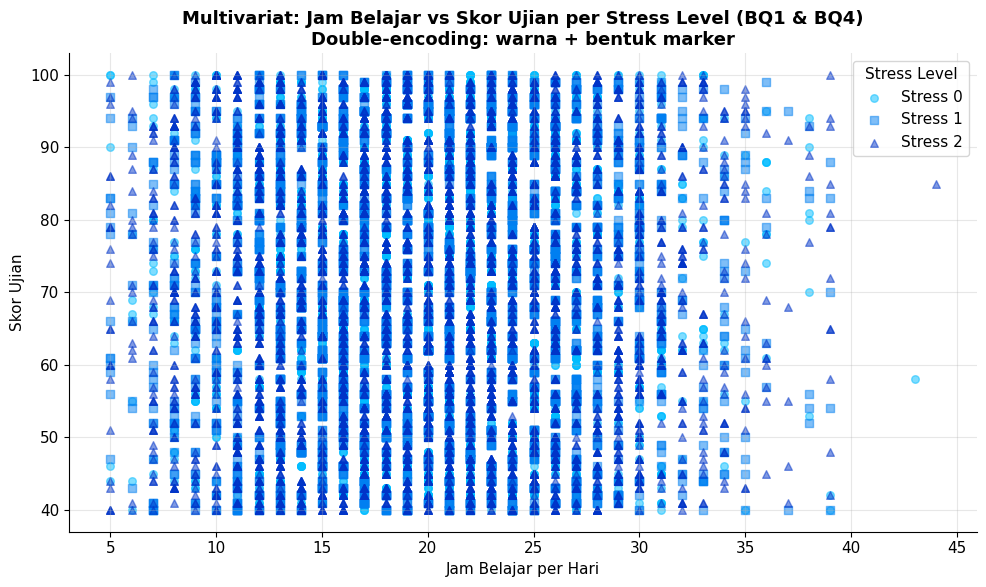

In [16]:
if all(c in df_lb_c.columns for c in ['StudyHours','ExamScore','StressLevel']):
    levels = sorted(df_lb_c['StressLevel'].dropna().unique())
    n = len(levels)
    cmap_3 = {l: PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i, l in enumerate(levels)}
    mkr = {l: m for l, m in zip(levels, ['o','s','^','D','v'])}

    fig, ax = plt.subplots(figsize=(10, 6))
    for level in levels:
        mask = df_lb_c['StressLevel'] == level
        ax.scatter(df_lb_c.loc[mask,'StudyHours'], df_lb_c.loc[mask,'ExamScore'],
                   c=cmap_3[level], marker=mkr.get(level,'o'), alpha=0.5, s=30, label=f'Stress {level}')
    ax.set_xlabel('Jam Belajar per Hari')
    ax.set_ylabel('Skor Ujian')
    ax.legend(title='Stress Level')
    ax.set_title('Multivariat: Jam Belajar vs Skor Ujian per Stress Level (BQ1 & BQ4)\nDouble-encoding: warna + bentuk marker',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('multi_scatter_3var_lb.png', dpi=150, bbox_inches='tight')
    plt.show()

**Scatter 3 Variabel**

Variabel ketiga (`StressLevel`) dikodekan dengan warna *dan* bentuk marker secara bersamaan (*double-encoding*) untuk mempertahankan aksesibilitas dan mempermudah pemisahan antar kelompok.

### Rekomendasi Pemodelan

In [17]:
print('Ringkasan EDA: Study Behavior')
print(f'learning_behavior  : {len(df_lb_c):,} baris')
print(f'academic_stress_rw : {len(df_as_c):,} baris')
if 'StressLevel' in df_lb_c.columns:
    print('\nDistribusi StressLevel:')
    print(df_lb_c['StressLevel'].value_counts())
if 'academic_stress_index' in df_as_c.columns:
    print(f'\nacademic_stress_index: mean={df_as_c["academic_stress_index"].mean():.3f}, max={df_as_c["academic_stress_index"].max():.3f}')

Ringkasan EDA: Study Behavior
learning_behavior  : 12,469 baris
academic_stress_rw : 140 baris

Distribusi StressLevel:
StressLevel
2    6331
1    3614
0    2524
Name: count, dtype: int64

academic_stress_index: mean=3.721, max=5.000


**Rekomendasi**

- Jika korelasi `StudyHours` vs `ExamScore` positif dan signifikan (r > 0.5), rekomendasikan model **Regresi** untuk prediksi skor ujian.
- Pola penurunan `Motivation` dan `Attendance` pada level stres tinggi mendukung penggunaan `Motivation` dan `Attendance` sebagai fitur prediksi stres dalam model **Klasifikasi**.
- Pertimbangkan *feature engineering*: interaction term `StudyHours * Motivation` untuk menangkap efek gabungan belajar aktif dan motivasi.